# Figure 3 Supplemental S8 — Rate of familiarization & modulation by task engagement

Split out from `figure_3_supplemental.ipynb`. Contains shared setup, the standalone exposure-level / within-session-epoch / active-vs-passive plots that feed the S8 composite, the shared SVM decoding cell (panel F), and the S8 composite assembly.

### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

# Statistical analysis
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from scipy.stats import chi2

# Data access
from visual_behavior.data_access import loading as loading
import visual_behavior.data_access.utilities as utilities
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

# Utilities
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

# NOTE: %autoreload 2 was removed -- it reloads the entire visual_behavior +
# allensdk module tree before EVERY cell, which destabilizes and kills the
# kernel on these heavy-loading notebooks (dies at a random cell each run). To
# hot-reload just your plotting code while developing, without the crash, use:
#     %load_ext autoreload
#     %autoreload 1
#     %aimport visual_behavior.visualization.ophys.platform_paper_figures
%matplotlib inline

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

### Configuration

In [2]:
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_3_supplemental')
folder = 'population_activity'

# Create save directories if they don't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists(os.path.join(save_dir, folder)):
    os.makedirs(os.path.join(save_dir, folder))

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

### Data Loading

#### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
behavior_sessions = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_behavior_sessions_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Load data tables

In [4]:
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


## SVM decoding (image identity from omissions — S8 panel F)
Loads the aggregated all_sess SVM decoding data for `decode_next_image_from_omissions` and builds the across-project-code aggregate. The labeled df / time axis / window metrics are stashed in `svm_agg` for the S8 composite below.

In [5]:
# ============================================================================
# SVM decoding (aggregated across project codes) -- S8 panel F only
# Loads the all_sess SVM decoding aggregate for image-identity decoding
# (decode_next_image_from_omissions) and stashes the labeled df / common time
# axis / window metrics in `svm_agg` for the S8 composite below.
# Mirrors load_svm_decoding_results.ipynb (other decode types trimmed -- not in S8).
# ============================================================================
import re
import glob
import importlib
importlib.reload(ppf)   # pick up the decoding functions added to platform_paper_figures.py

svm_project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']
_svm_dir = os.path.join(loading.get_platform_analysis_cache_dir(), 'visual_behavior_ophys_decoding')
svm_metrics_dir = os.path.join(_svm_dir, 'window_metrics')

_SVM_PC_RE = re.compile(r'_(VisualBehaviorMultiscope|VisualBehaviorTask1B|VisualBehavior)_\d{8}_\d{6}\.h5$')
_SVM_TS_RE = re.compile(r'_(\d{8})_(\d{6})\.h5$')


def _svm_project_code(b):
    m = _SVM_PC_RE.search(b)
    return m.group(1) if m else None


def _svm_timestamp(b):
    m = _SVM_TS_RE.search(b)
    return (m.group(1) + m.group(2)) if m else ''


def find_svm_events_file(decoding_type, project_code):
    """Latest standard all_sess events aggregate for a (decoding_type, project_code)."""
    keep = []
    for f in glob.glob(os.path.join(_svm_dir, 'all_sess_events_svm_%s_*.h5' % decoding_type)):
        b = os.path.basename(f)
        if 'matched_cells' in b or 'sameNumNeurons' in b:
            continue
        if _svm_project_code(b) != project_code:
            continue
        keep.append(f)
    keep.sort(key=lambda f: _svm_timestamp(os.path.basename(f)))
    return keep[-1] if keep else None


svm_decoding_types = ['decode_next_image_from_omissions']  # S8 panel F (image identity)
svm_results, svm_input_vars = {}, {}
for _dt in svm_decoding_types:
    svm_results[_dt], svm_input_vars[_dt] = {}, {}
    for _pc in svm_project_codes:
        _fp = find_svm_events_file(_dt, _pc)
        if _fp is None:
            print('[missing] %s / %s' % (_dt, _pc))
            continue
        svm_results[_dt][_pc] = pd.read_hdf(_fp, key='all_sess')
        try:
            svm_input_vars[_dt][_pc] = pd.read_hdf(_fp, key='input_vars')
        except KeyError:
            svm_input_vars[_dt][_pc] = None
        print('[ok] %s / %s: %s' % (_dt, _pc, os.path.basename(_fp)))

# aggregate across project codes; stash for the composite
svm_agg = {}
for _dt in svm_decoding_types:
    _combined, _t = ppf.resample_decoding_across_projects(
        svm_results, svm_input_vars, _dt, svm_project_codes)
    _labeled = ppf.add_decoding_labels(_combined, platform_experiments)
    _wm = ppf.get_decoding_window_metrics(
        _labeled, _dt, _t, metrics_dir=svm_metrics_dir, tag='aggregated', recompute=False)
    svm_agg[_dt] = dict(labeled=_labeled, t=_t, wm=_wm)

[ok] decode_next_image_from_omissions / VisualBehavior: all_sess_events_svm_decode_next_image_from_omissions_frames-15to22_VisualBehavior_20220113_203717.h5
[ok] decode_next_image_from_omissions / VisualBehaviorTask1B: all_sess_events_svm_decode_next_image_from_omissions_frames-15to22_VisualBehaviorTask1B_20220113_203449.h5
[ok] decode_next_image_from_omissions / VisualBehaviorMultiscope: all_sess_events_svm_decode_next_image_from_omissions_frames-5to7_VisualBehaviorMultiscope_20220114_105103.h5


## Figure S8 composite (assembled)

*Rate of familiarization, modulation by task engagement.* Two schematic strips (image change / image omission) left blank. Requires the earlier slow-load mdfs and the SVM cell (with the image-identity decode type) to have run.

In [ ]:
# ==========================================================================
# S8 data loading
# Builds ONLY the base mdfs the S8 composite needs. Each large multi-session df
# is released from memory (del + gc.collect) as soon as the needed subset is
# taken, so peak RAM stays well under the machine limit. (The full
# multi_session_df pickles are 5-13 GB each; without this cleanup the kernel
# is OOM-killed.)
# Prereqs from earlier cells: data_type, inclusion_criteria, interpolate,
# output_sampling_rate, platform_experiments.
# ==========================================================================
import gc

# --- control_change_mdf (all sessions, image changes) -> panels A & B ---
control_mdf = loading.get_multi_session_df_for_conditions(
    data_type, 'all', ['cell_specimen_id', 'is_change'], inclusion_criteria='all',
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)
control_change_mdf = control_mdf[control_mdf.is_change == True].copy()
del control_mdf
gc.collect()
print(f'{len(control_change_mdf.ophys_experiment_id.unique())} experiments, '
      f'{len(control_change_mdf.cell_specimen_id.unique())} cells')

# --- active_passive_experiment_table -> panels D, E, H, I ---
active_passive_experiment_table = loading.get_active_passive_sessions_for_platform_dataset()

# --- passive_change_mdf (active/passive change responses) -> panels D & E ---
passive_change_mdf = loading.get_multi_session_df_for_conditions(
    data_type, 'all', ['cell_specimen_id', 'is_change'], 'platform_active_passive',
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)
passive_change_mdf = passive_change_mdf[passive_change_mdf.is_change == True].copy()
gc.collect()

# --- change_mdf_epochs (within-session change response, 5-min epochs) -> panel C ---
epoch_duration_mins = 5
img_change_mdf_epochs = loading.get_multi_session_df_for_conditions(
    data_type, 'all', ['cell_specimen_id', 'is_change', 'epoch'], inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=epoch_duration_mins)
change_mdf_epochs = img_change_mdf_epochs[img_change_mdf_epochs.is_change == True].copy()
# Limit to multi-plane imaging to enable depth comparisons
change_mdf_epochs = change_mdf_epochs[change_mdf_epochs.project_code.isin(['VisualBehaviorMultiscope'])]
del img_change_mdf_epochs
gc.collect()

# --- passive_omission_mdf (active/passive omission responses) -> panels H & I ---
passive_omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type, 'all', ['cell_specimen_id', 'omitted'], 'platform_active_passive',
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)
passive_omission_mdf = passive_omission_mdf[passive_omission_mdf.omitted == True].copy()
gc.collect()
print(f'{len(passive_omission_mdf.mouse_id.unique())} mice, '
      f'{len(passive_omission_mdf.ophys_experiment_id.unique())} experiments, '
      f'{len(passive_omission_mdf.cell_specimen_id.unique())} cells')

# --- omission_mdf_epochs (within-session omission response, 5-min epochs) -> panel G ---
omission_mdf_epochs = loading.get_multi_session_df_for_conditions(
    data_type, 'all', ['cell_specimen_id', 'omitted', 'epoch'], inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=epoch_duration_mins)
omission_mdf_epochs = omission_mdf_epochs[omission_mdf_epochs.omitted == True].copy()
omission_mdf_epochs = omission_mdf_epochs[omission_mdf_epochs.project_code.isin(['VisualBehaviorMultiscope'])]
omission_mdf_epochs['epoch'] = omission_mdf_epochs['epoch'] + 1
gc.collect()

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_all.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_all.feather
there are 1881 experiments in the full multi_session_df


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

removing 1 problematic experiments
there are 1874 experiments after filtering for inclusion criteria -  all
1874 experiments, 39997 cells


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

...

removing 1 problematic experiments
1243 total experiments
402 platform experiments
134 platform containers
854 experiments in platform dataset
134 containers in platform dataset
3 experience levels in platform dataset
233 passive expts closest to first novel day


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/loading.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_platform_experiments['experience_level'] = [utils.convert_experience_level(experience_level) for
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/utilities.py:1784: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['date_of_acquisition'].apply(dateformat)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual

268 active expts closest to first novel day
501 merged passive and active expts
134 containers in active passive set
there are 499 experiments in the multi_session_df after limiting to active-passive experiments from platform paper containers
there are 499 experiments after filtering for inclusion criteria -  platform_active_passive


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_epoch_epoch_dur_5_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_epoch_epoch_dur_5_platform_experiment_table.feather
there are 1885 experiments in the full multi_session_df


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
OVERLAP: axes of panel "E" intrudes into panel "E" (left gutter)


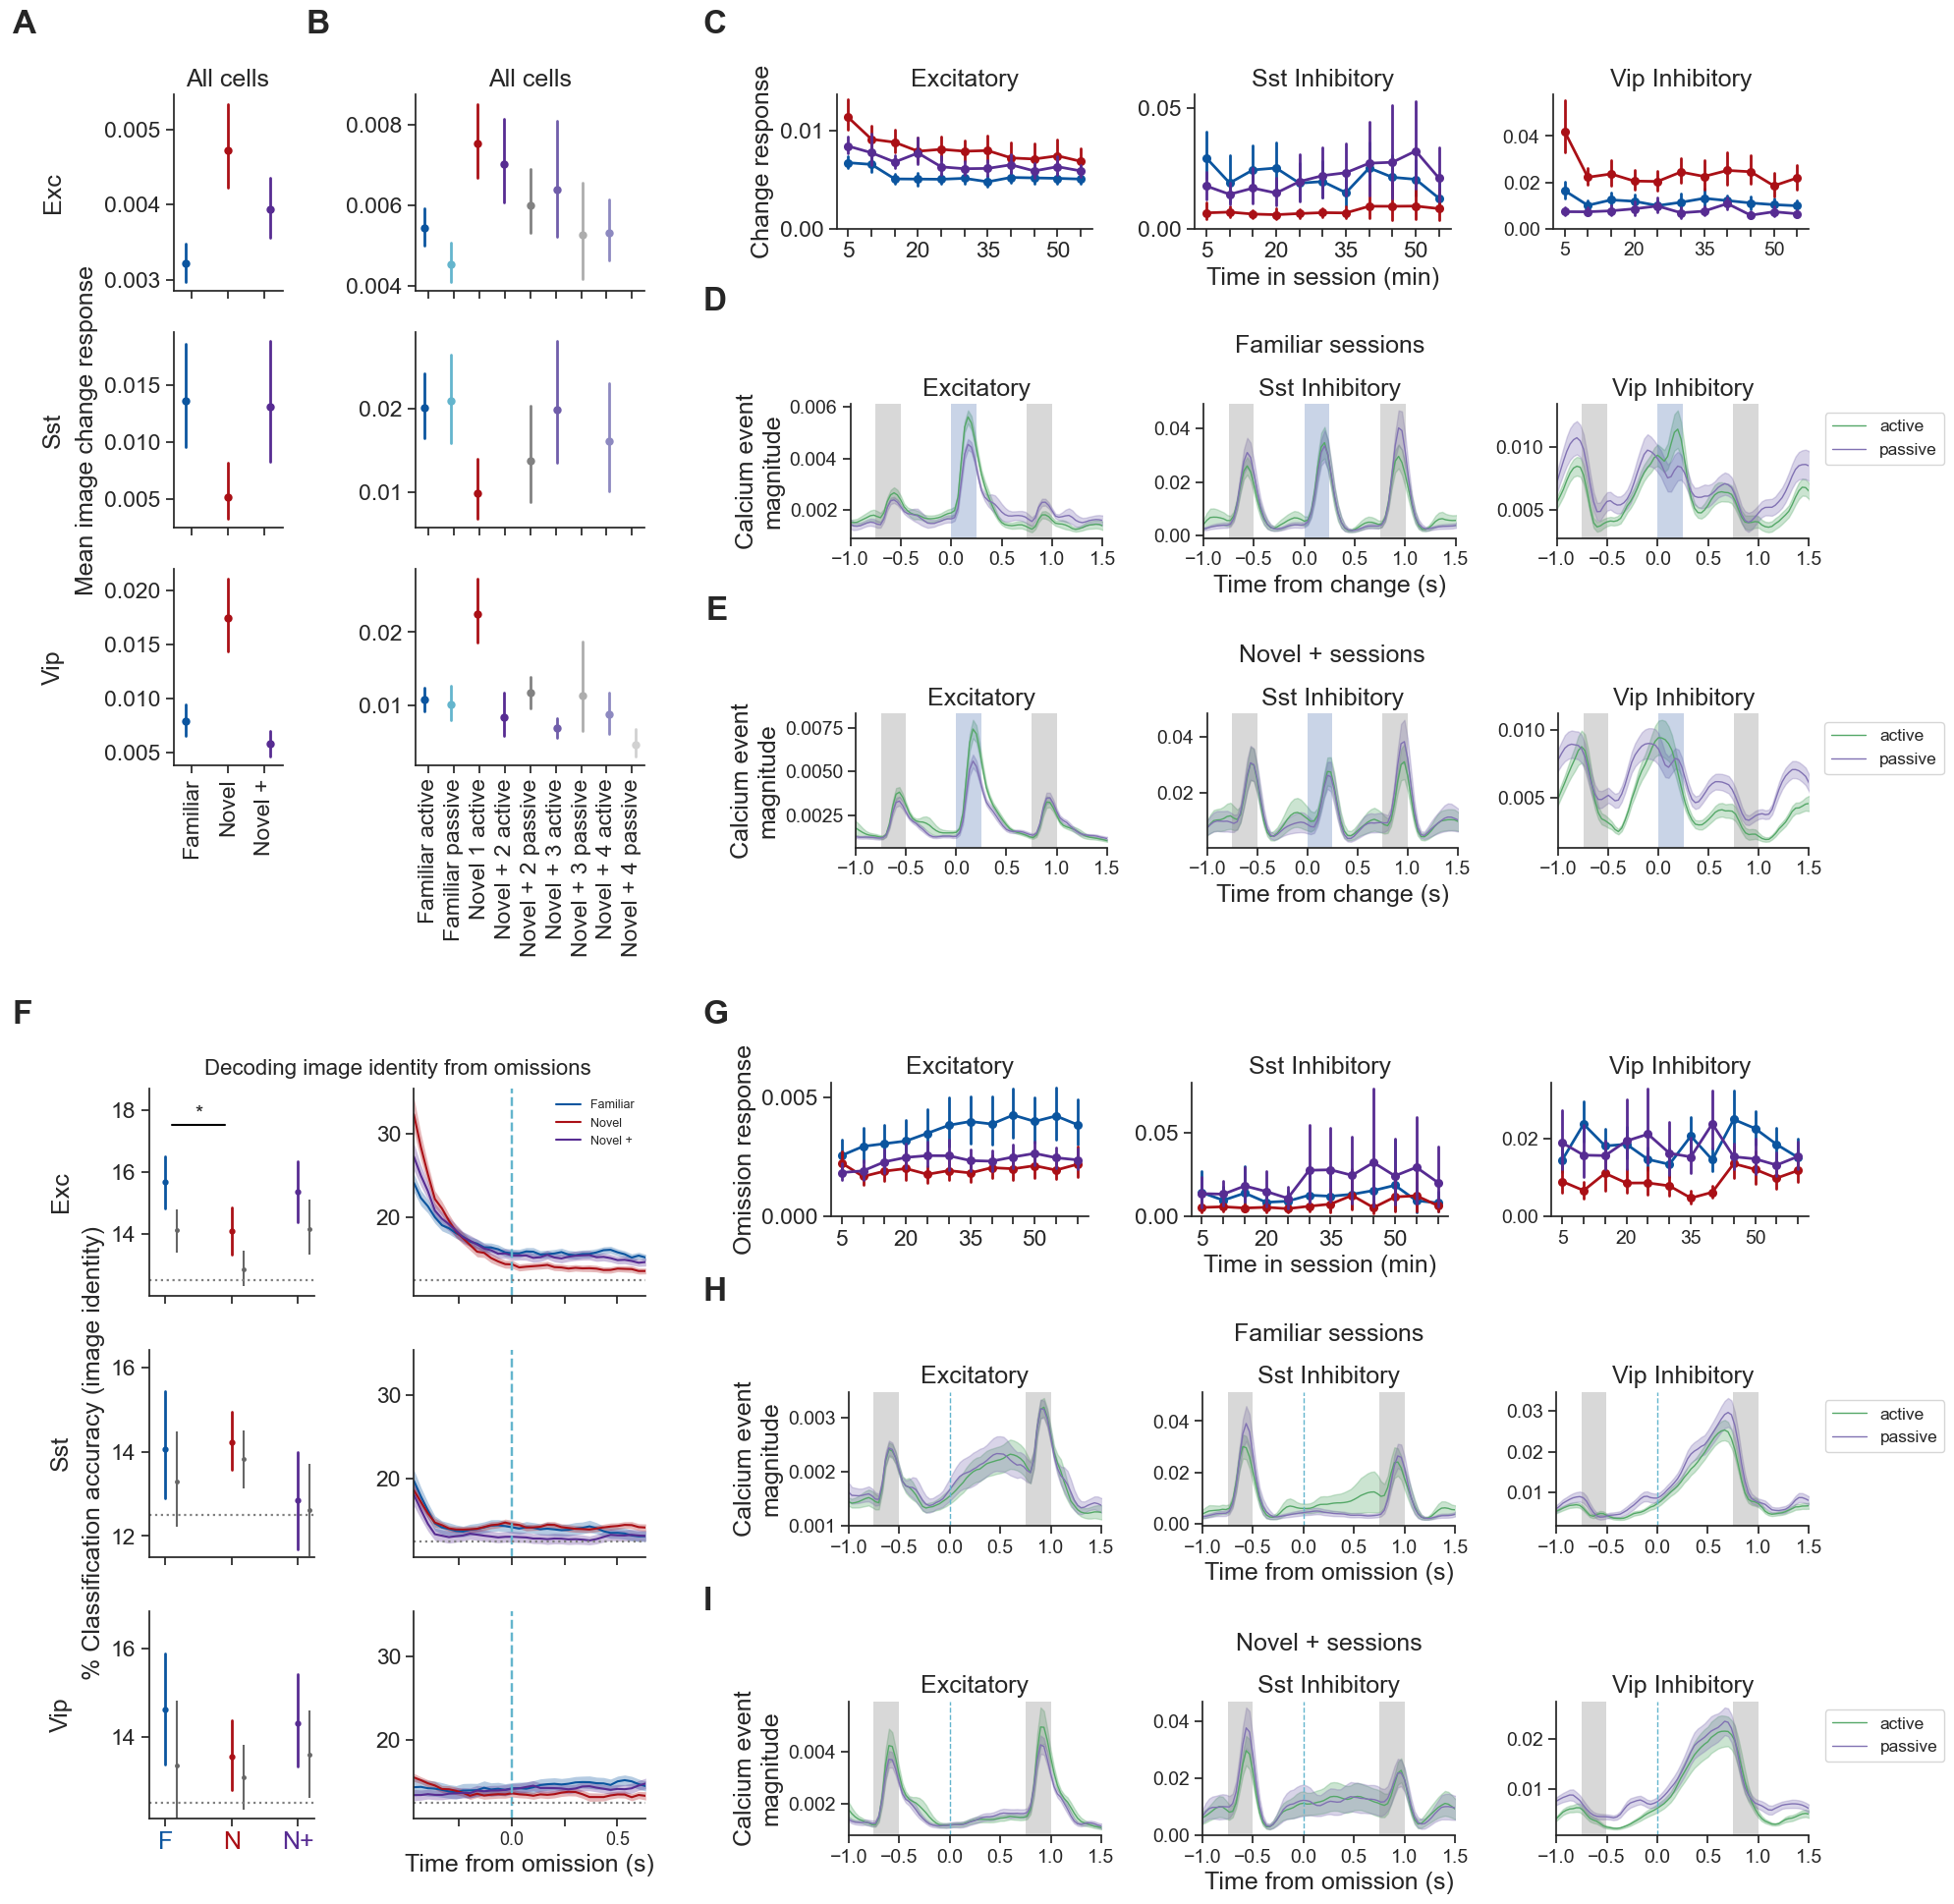

In [ ]:
# ==========================================================================
# Figure S8 composite  (Rate of familiarization, modulation by task engagement)
# Two schematic strips ("Image change" above A/C, "Image omission" between E and F)
# are intentionally left BLANK (no panel) per the design.
#
# Each panel rebuilds its data from the STABLE base mdfs loaded in the cell above.
# Panel B reconstructs its own df/levels/colors here from `control_change_mdf`.
#
# Requires (all built by the "S8 data loading" cell above):
#   control_change_mdf, change_mdf_epochs, omission_mdf_epochs,
#   passive_change_mdf, passive_omission_mdf, active_passive_experiment_table,
#   platform_experiments, and svm_agg['decode_next_image_from_omissions'].
# Run order: imports -> config -> metadata -> SVM cell -> S8 data loading -> this.
# ==========================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from visual_behavior.visualization.panel_grid import (
    fig_setup, panel, show_label_gutters, check_label_overlap,
    auto_fit_bottom, snug_left_to_gutter, snug_top_to_gutter)

sns.set_context('notebook', font_scale=1.5)
CT = utils.get_cell_types()

FIGSIZE = (18.5, 21.0)
REGIONS = {
    'A': [0.0,    0.1555, 0.0713, 0.5064], 'B': [0.1685, 0.3523, 0.0713, 0.5064],
    'C': [0.3848, 0.9959, 0.0713, 0.2024],
    'D': [0.3827, 0.9959, 0.2064, 0.3364],
    'E': [0.3858, 0.9959, 0.3404, 0.4851],
    'F': [0.0041, 0.3523, 0.55,   0.9734],
    'G': [0.3817, 0.9949, 0.5617, 0.7109],
    'H': [0.3817, 0.9949, 0.7149, 0.8407],
    'I': [0.3817, 0.9949, 0.8447, 0.9872],
}

# Even vertical grid for the right-column response rows (C/D/E top, G/H/I bottom).
# Every plot gets the same spine height (_RC_H) and the same spine-top pitch (_RC_P)
# within a triplet. The top triplet starts at C's top; the bottom triplet starts at
# F's top so the G panel letter lines up with F. D/E/H/I carry one extra header line
# (the active/passive row title), so their region tops sit one title line higher,
# which keeps the PLOTS evenly spaced even though the headers differ.
_pt = 1.0 / 72 / FIGSIZE[1]
_RC_H = 0.065                       # plot spine height (identical for all six rows)
_RC_P = 0.150                       # spine-top-to-spine-top pitch within a triplet
_RC_GUT = 28 * _pt                  # label-gutter height (matches DEFAULT_LABEL_GUTTER_PT)
_RC_LINE = 28 * _pt                 # one title line (matches DEFAULT_TITLE_ROOM_PT)
_rc_spine = {'C': REGIONS['C'][2] + _RC_GUT + _RC_LINE,
             'G': REGIONS['F'][2] + _RC_GUT + _RC_LINE}
_rc_spine['D'] = _rc_spine['C'] + _RC_P
_rc_spine['E'] = _rc_spine['C'] + 2 * _RC_P
_rc_spine['H'] = _rc_spine['G'] + _RC_P
_rc_spine['I'] = _rc_spine['G'] + 2 * _RC_P
_rc_lines = {'C': 1, 'D': 2, 'E': 2, 'G': 1, 'H': 2, 'I': 2}
for _lbl, _st in _rc_spine.items():
    _x0, _x1 = REGIONS[_lbl][0], REGIONS[_lbl][1]
    REGIONS[_lbl] = [_x0, _x1, _st - _RC_GUT - _RC_LINE * _rc_lines[_lbl], _st + _RC_H + 0.028]

A_LEFT_DEC = 98          # A leftmost: long rotated metric label + cell-type outer text
F_LEFT_DEC = 90          # F leftmost decoding ylabel; also right-stack left decoration
WSPACE_ROW = 0.4         # within-row spacing for 1x3 panels (C/D/E/G/H/I)
ap_palette = [sns.color_palette()[2], sns.color_palette()[4]]   # active (green) / passive (purple)


def _row_header(axlist, region, text):
    """Centered text just above the cell-type titles, close to the plot axes."""
    ps = [a.get_position() for a in axlist]
    x = (min(p.x0 for p in ps) + max(p.x1 for p in ps)) / 2
    y = max(p.y1 for p in ps) + (34 / 72 / FIGSIZE[1])
    fig.text(x, y, text, ha='center', va='bottom', fontsize=18)


fig = plt.figure(figsize=FIGSIZE)
fig_setup(fig)

# ---------------- Image change section (A-E) ----------------

# ---- A: mean image change response, All cells by experience (F/N/N+) ----
tmpA = control_change_mdf.copy()
tmpA = tmpA[tmpA.project_code != 'VisualBehaviorMultiscope4areasx2d']
tmpA = utilities.limit_to_containers_with_all_experience_levels(tmpA)
tmpA = tmpA[tmpA.ophys_experiment_id.isin(platform_experiments.index.values)]
axA = panel(fig, REGIONS['A'][:2], REGIONS['A'][2:], 'A', has_title=True, dim=(3, 1),
            decoration_pt=(A_LEFT_DEC, 0))
ppf.plot_metric_across_exposures(
    tmpA, 'mean_response', 'Mean image change response', plot_type='pointplot',
    x_val='experience_level', x_vals=utils.get_experience_levels(),
    palette=utils.get_experience_level_colors(), save_dir=None, folder=None, ax=axA)
for a in axA:
    a.set_ylabel(''); a.set_title('')
axA[1].set_ylabel('Mean image change response')
axA[0].set_title('All cells')
for a in axA[:-1]:
    a.tick_params(labelbottom=False)

# ---- B: mean image change response across exposures, active/passive ----
# reconstruct df/levels/colors from the stable base mdf (cells "Exposure level analysis")
_dfB = control_change_mdf.copy()
_dfB = _dfB[_dfB.project_code == 'VisualBehaviorMultiscope']
_dfB = utilities.limit_to_containers_with_all_experience_levels(_dfB)
_nps = _dfB[_dfB.prior_exposures_to_image_set <= 3].ophys_session_id.unique()
_fss = _dfB[(_dfB.experience_level == 'Familiar') & (_dfB.n_relative_to_first_novel <= 3)].ophys_session_id.unique()
_dfB = _dfB[_dfB.ophys_session_id.isin(np.hstack([_nps, _fss]))]
_dfB['prior_exposures_to_image_set'] = [int(x) for x in _dfB.prior_exposures_to_image_set.values]
def _passive_str(p):
    return 'passive' if p else 'active'
_dfB['experience_level'] = [
    _dfB.iloc[i].experience_level + ' ' + str(_dfB.iloc[i].prior_exposures_to_image_set + 1) + ' ' + _passive_str(_dfB.iloc[i].passive)
    if 'Familiar' not in _dfB.iloc[i].experience_level
    else _dfB.iloc[i].experience_level + ' ' + _passive_str(_dfB.iloc[i].passive)
    for i in range(len(_dfB))]
_levels = np.sort(_dfB.experience_level.unique())
_levels = list(_levels[:2]) + [_levels[-1]] + list(_levels[2:-1])
_ec = utils.get_experience_level_colors()
_active_colors = sns.color_palette('Purples_r', 6)[:3]
_passive_colors = sns.color_palette('Greys_r', 6)[2:6]
_colors = [_ec[0], sns.color_palette()[9], _ec[1],
           _active_colors[0], _passive_colors[0],
           _active_colors[1], _passive_colors[1],
           _active_colors[2], _passive_colors[2]]
axB = panel(fig, REGIONS['B'][:2], REGIONS['B'][2:], 'B', has_title=True, dim=(3, 1))
ppf.plot_metric_across_exposures(
    _dfB, 'mean_response', 'Mean image change response', plot_type='pointplot',
    x_val='experience_level', x_vals=_levels, palette=_colors, save_dir=None, folder=None, ax=axB)
for a in axB:
    a.set_ylabel(''); a.set_title('')
axB[0].set_title('All cells')
for a in axB[:-1]:
    a.tick_params(labelbottom=False)

# ---- C: within-session change response across mins (1x3) ----
axC = panel(fig, REGIONS['C'][:2], REGIONS['C'][2:], 'C', has_title=True, dim=(1, 3),
            wspace=WSPACE_ROW, decoration_pt=(F_LEFT_DEC, 0))
ppf.plot_mean_response_by_epoch(
    change_mdf_epochs, metric='mean_response', horizontal=True, ymin=0,
    ylabel='Change response', estimator=np.mean, epoch_dur_mins=5,
    markersize=5, linewidth=2.0, err_linewidth=2.0,
    save_dir=None, folder=None, max_epoch=11, suptitle=None, suffix='',
    ax=list(np.array(axC).ravel()))
for a in (axC[1], axC[2]):
    a.set_ylabel('')
# label only every 3rd x-tick (keep all tick marks)
for a in axC:
    _labs = [t.get_text() for t in a.get_xticklabels()]
    a.set_xticklabels([s if i % 3 == 0 else '' for i, s in enumerate(_labs)])
for a in axC:
    a.set_xlabel('')
axC[1].set_xlabel('Time in session (min)')

# ---- D: active vs passive change pop avg, Familiar (1x3) ----
_dfD = passive_change_mdf.copy()
_dfD = _dfD[_dfD.ophys_experiment_id.isin(active_passive_experiment_table.index.values)]
_dfD = _dfD[_dfD.experience_level == 'Familiar']
axD = panel(fig, REGIONS['D'][:2], REGIONS['D'][2:], 'D', has_title=True, title_lines=2, dim=(1, 3),
            wspace=WSPACE_ROW, decoration_pt=(F_LEFT_DEC, 0))
ppf.plot_population_averages_for_conditions(
    _dfD, data_type, 'changes', 'cell_type', 'passive', horizontal=True,
    ylabel='Calcium event\nmagnitude', xlabel='Time from image change (s)',
    xlim_seconds=[-1., 1.5], interval_sec=0.5, palette=ap_palette, legend=True,
    suptitle=None, save_dir=None, ax=list(np.array(axD).ravel()))
for a in (axD[1], axD[2]):
    a.set_ylabel('')


# ---- E: active vs passive change pop avg, Novel + (1x3) ----
_dfE = passive_change_mdf.copy()
_dfE = _dfE[_dfE.ophys_experiment_id.isin(active_passive_experiment_table.index.values)]
_dfE = _dfE[_dfE.experience_level == 'Novel +']
axE = panel(fig, REGIONS['E'][:2], REGIONS['E'][2:], 'E', has_title=True, title_lines=2, dim=(1, 3),
            wspace=WSPACE_ROW, decoration_pt=(F_LEFT_DEC, 0))
ppf.plot_population_averages_for_conditions(
    _dfE, data_type, 'changes', 'cell_type', 'passive', horizontal=True,
    ylabel='Calcium event\nmagnitude', xlabel='Time from image change (s)',
    xlim_seconds=[-1., 1.5], interval_sec=0.5, palette=ap_palette, legend=True,
    suptitle=None, save_dir=None, ax=list(np.array(axE).ravel()))
for a in (axE[1], axE[2]):
    a.set_ylabel('')

# ---------------- Image omission section (F-I) ----------------

# ---- F: image-identity decoding (window summary + timecourse), 3x2 ----
_dtF = 'decode_next_image_from_omissions'
_agF = svm_agg[_dtF]
axF = panel(fig, REGIONS['F'][:2], REGIONS['F'][2:], 'F', dim=(3, 2),
            width_ratios=[1, 1.4], wspace=0.5, hspace=0.0, decoration_pt=(F_LEFT_DEC, 28))
_F0 = [axF[r][0] for r in range(3)]   # window-summary point-plots
_F1 = [axF[r][1] for r in range(3)]   # time-resolved traces
ppf.plot_decoding_window_summary(_agF['wm'], _dtF, axes=_F0)
ppf.plot_decoding_timecourse(_agF['labeled'], _dtF, _agF['t'], axes=_F1)
for _a in _F0 + _F1:
    _a.set_title('')
for _a in (_F0[0], _F0[1], _F1[0], _F1[1]):
    _a.tick_params(labelbottom=False)
_F0[1].set_ylabel('% Classification accuracy (image identity)')
_F1[1].set_ylabel('')
_F0[2].tick_params(axis='x', labelsize=18)
_legF = _F1[0].get_legend()
if _legF is not None:
    _hF = _legF.legend_handles
    _lF = [_t.get_text() for _t in _legF.get_texts()]
    _F1[0].legend(_hF, _lF, loc='upper right', frameon=False, fontsize=9)
# share y-range across the right (timecourse) column
_yl_F1 = (min(a.get_ylim()[0] for a in _F1), max(a.get_ylim()[1] for a in _F1))
for _a in _F1:
    _a.set_ylim(_yl_F1)

# ---- G: within-session omission response across mins (1x3) ----
axG = panel(fig, REGIONS['G'][:2], REGIONS['G'][2:], 'G', has_title=True, dim=(1, 3),
            wspace=WSPACE_ROW, decoration_pt=(F_LEFT_DEC, 0))
ppf.plot_mean_response_by_epoch(
    omission_mdf_epochs, metric='mean_response', horizontal=True, ymin=0,
    ylabel='Omission response', estimator=np.mean, epoch_dur_mins=5,
    markersize=5, linewidth=2.0, err_linewidth=2.0,
    save_dir=None, folder=None, max_epoch=12, suptitle=None, suffix='',
    ax=list(np.array(axG).ravel()))
for a in (axG[1], axG[2]):
    a.set_ylabel('')
# label only every 3rd x-tick (keep all tick marks)
for a in axG:
    _labs = [t.get_text() for t in a.get_xticklabels()]
    a.set_xticklabels([s if i % 3 == 0 else '' for i, s in enumerate(_labs)])
for a in axG:
    a.set_xlabel('')
axG[1].set_xlabel('Time in session (min)')

# ---- H: active vs passive omission pop avg, Familiar (1x3) ----
_dfH = passive_omission_mdf.copy()
_dfH = _dfH[_dfH.ophys_experiment_id.isin(active_passive_experiment_table.index.values)]
_dfH = _dfH[_dfH.experience_level == 'Familiar']
axH = panel(fig, REGIONS['H'][:2], REGIONS['H'][2:], 'H', has_title=True, title_lines=2, dim=(1, 3),
            wspace=WSPACE_ROW, decoration_pt=(F_LEFT_DEC, 0))
ppf.plot_population_averages_for_conditions(
    _dfH, data_type, 'omissions', 'cell_type', 'passive', horizontal=True,
    ylabel='Calcium event\nmagnitude', xlabel='Time from image omission (s)',
    xlim_seconds=[-1., 1.5], interval_sec=0.5, palette=ap_palette, legend=True,
    suptitle=None, save_dir=None, ax=list(np.array(axH).ravel()))
for a in (axH[1], axH[2]):
    a.set_ylabel('')

# ---- I: active vs passive omission pop avg, Novel + (1x3) ----
_dfI = passive_omission_mdf.copy()
_dfI = _dfI[_dfI.ophys_experiment_id.isin(active_passive_experiment_table.index.values)]
_dfI = _dfI[_dfI.experience_level == 'Novel +']
axI = panel(fig, REGIONS['I'][:2], REGIONS['I'][2:], 'I', has_title=True, title_lines=2, dim=(1, 3),
            wspace=WSPACE_ROW, decoration_pt=(F_LEFT_DEC, 0))
ppf.plot_population_averages_for_conditions(
    _dfI, data_type, 'omissions', 'cell_type', 'passive', horizontal=True,
    ylabel='Calcium event\nmagnitude', xlabel='Time from image omission (s)',
    xlim_seconds=[-1., 1.5], interval_sec=0.5, palette=ap_palette, legend=True,
    suptitle=None, save_dir=None, ax=list(np.array(axI).ravel()))
for a in (axI[1], axI[2]):
    a.set_ylabel('')


# ---------------- fit + snug + headers + audit ----------------
# Only F is auto bottom-fit; A/B and the six right-column rows go on explicit grids
# below. auto_fit_bottom opens spurious gaps in multi-row panels -- it shifts every
# row up by the bottom-label overflow (~0.06 here) -- so those panels are excluded.
auto_fit_bottom(fig, {k: v for k, v in REGIONS.items() if k == 'F'}, pad_pt=2)
snug_left_to_gutter(fig, REGIONS, only=['B', 'C', 'D', 'E', 'G', 'H', 'I'])
# F: reserve an extra band left of the y-axis decoration for per-row cell-type
# labels (this also narrows F's plots, pulling them right of the label gutter).
_F_LABEL_BAND_PT = 26
snug_left_to_gutter(fig, REGIONS, only=['F'], gutter_pt=(20 + _F_LABEL_BAND_PT, 28))

# A & B: stack the three rows on one shared tight grid (equal heights, small gap) so
# their y-axis spines align top-and-bottom and the inter-row whitespace is minimal.
# B's long rotated x-tick labels overflow downward into the empty band below row 2.
_ab_top = REGIONS['A'][2] + _RC_GUT + _RC_LINE      # row-0 spine top, just under the title gutter
_ab_h = 0.095                                        # row spine height (shared by A & B)
_ab_gap = 0.02                                       # inter-row gap
fig.canvas.draw()
for _axcol in (axA, axB):
    for _r, _a in enumerate(_axcol):
        _top_td = _ab_top + _r * (_ab_h + _ab_gap)
        _p = _a.get_position()
        _a.set_position([_p.x0, 1 - (_top_td + _ab_h), _p.width, _ab_h])

# Lock the six right-column rows to the exact equal-height even grid (snug_left set
# their x; here we set y), so every response plot shares one height and pitch and the
# titles/headers sit right under each top gutter.
fig.canvas.draw()
for _lbl, _axes in {'C': axC, 'D': axD, 'E': axE, 'G': axG, 'H': axH, 'I': axI}.items():
    _bot_bu = 1 - (_rc_spine[_lbl] + _RC_H)
    for _a in _axes:
        _p = _a.get_position()
        _a.set_position([_p.x0, _bot_bu, _p.width, _RC_H])

# A: cell-type outer labels as fixed-x annotations (align across rows)
fig.canvas.draw()
_gx = 20 / 72 / FIGSIZE[0]
_x_ct = REGIONS['A'][0] + _gx + 0.009
_fs = plt.rcParams['axes.labelsize']
for _a, _ct in zip(axA, CT):
    _p = _a.get_position()
    fig.text(_x_ct, (_p.y0 + _p.y1) / 2, _ct[:3], rotation=90, ha='center', va='center', fontsize=_fs)

# row headers (the active/passive condition) above D/E/H/I
fig.canvas.draw()
_row_header(axD, REGIONS['D'], 'Familiar sessions')
_row_header(axE, REGIONS['E'], 'Novel + sessions')
_row_header(axH, REGIONS['H'], 'Familiar sessions')
_row_header(axI, REGIONS['I'], 'Novel + sessions')

# "Population decoding" suptitle over F's two columns
fig.canvas.draw()
_fp0 = _F0[0].get_position(); _fp1 = _F1[0].get_position()
fig.text((_fp0.x0 + _fp1.x1) / 2, max(_fp0.y1, _fp1.y1) + 0.005, 'Decoding image identity from omissions',
         ha='center', va='bottom', fontsize=16)

# F: cell-type outer labels (one per row), mirroring panel A's cell-type column
fig.canvas.draw()
_x_ct_F = REGIONS['F'][0] + _gx + 0.009
for _a, _ct in zip(_F0, CT):
    _p = _a.get_position()
    fig.text(_x_ct_F, (_p.y0 + _p.y1) / 2, _ct[:3], rotation=90, ha='center', va='center', fontsize=_fs)

check_label_overlap(fig, REGIONS)
utils.save_figure(fig, FIGSIZE, save_dir, 'composite', 'figure_S8_composite')
plt.show()
